# 01 - EDA: Du doan gia xe o to cu

Notebook nay chay tren Google Colab. Truoc khi chay:
1. Upload `ai-models/data/dataset.zip` (hoac giai nen san `data.csv`) len Colab, hoac mount Google Drive.
2. `!pip install -q pandas matplotlib seaborn scikit-learn joblib`
3. Sua `DATA_PATH` ben duoi cho dung vi tri file `data.csv` sau khi giai nen `dataset.zip`.

In [ ]:
import sys, os
# Neu chay trong repo (khong phai Colab), them src/ vao path de import data_utils
sys.path.insert(0, os.path.join('..', 'src'))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_utils import load_raw, clean_dataframe, NUMERIC_FEATURES
sns.set_theme(style='whitegrid')

DATA_PATH = '../data/data.csv'  # giai nen tu dataset.zip
raw = load_raw(DATA_PATH)
print('Raw shape:', raw.shape)
raw.head()

## Buoc 0: Mo ta bai toan

- **Nguon du lieu:** ~27.000 tin rao ban xe cu tren bonbanh.com (Kaggle: `danh911/gi-xe`).
- **Loai bai toan:** Hoi quy (Regression) - du doan `price` (gia xe, don vi trieu VND) tu cac dac trung cua xe.
- **Dac trung dau vao:** hang xe, dong xe, kieu dang (series), nam san xuat, so km da di, xuat xu lap rap, loai nhien lieu, hop so, so cua, so cho ngoi.

In [ ]:
df = clean_dataframe(raw)
print('Clean shape:', df.shape)
df.head()

Clean shape: (24723, 11)


## Hinh 1: Phan bo bien muc tieu (price)

**Quan sat:** Gia xe lech phai rat manh (median ~570 trieu, nhung co duoi dai toi vai chuc ty). Sau khi lay `log1p`, phan bo gan doi xung hon.

**Y nghia:** Neu huan luyen truc tiep tren `price` goc, cac model se bi anh huong manh boi mot so xe rat dat (outlier ve gia tri).

**Quyet dinh xu ly:** Bien doi target bang `log1p` khi huan luyen (`TransformedTargetRegressor`), du doan xong doi nguoc bang `expm1`. Cac metric danh gia (MAE, RMSE, R2) van tinh tren gia tri goc (trieu VND) de de dien giai.

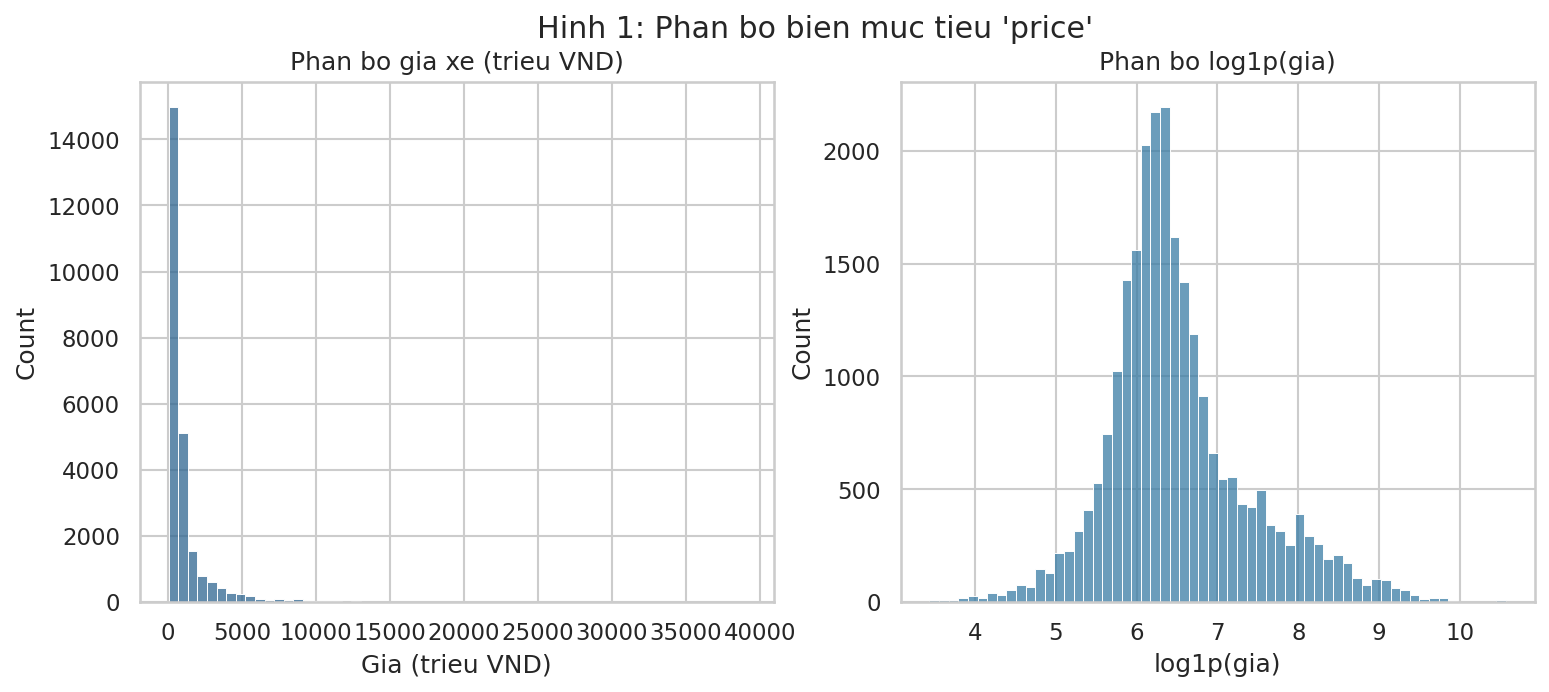

In [ ]:
import matplotlib.image as mpimg
img = mpimg.imread('../../docs/figures/01_target_distribution.png')
plt.figure(figsize=(12,4.5)); plt.imshow(img); plt.axis('off'); plt.show()

## Hinh 2: Phan bo va ngoai lai cac bien so

**Quan sat:** `driven_kms` co mot so gia tri rat lon (ngoai lai); `year` tap trung tu ~2005-2023; `price` co nhieu diem ngoai lai phia tren khi ve boxplot.

**Y nghia:** Can chan nguong hop ly cho km va gia truoc khi dua vao model, tranh de du lieu loi crawl anh huong ket qua.

**Quyet dinh xu ly:** Loc `driven_kms <= 1.000.000 km`, `price` trong khoang 30 trieu - 60 ty, `num_of_door` trong [2,6], `num_of_seat` trong [2,16].

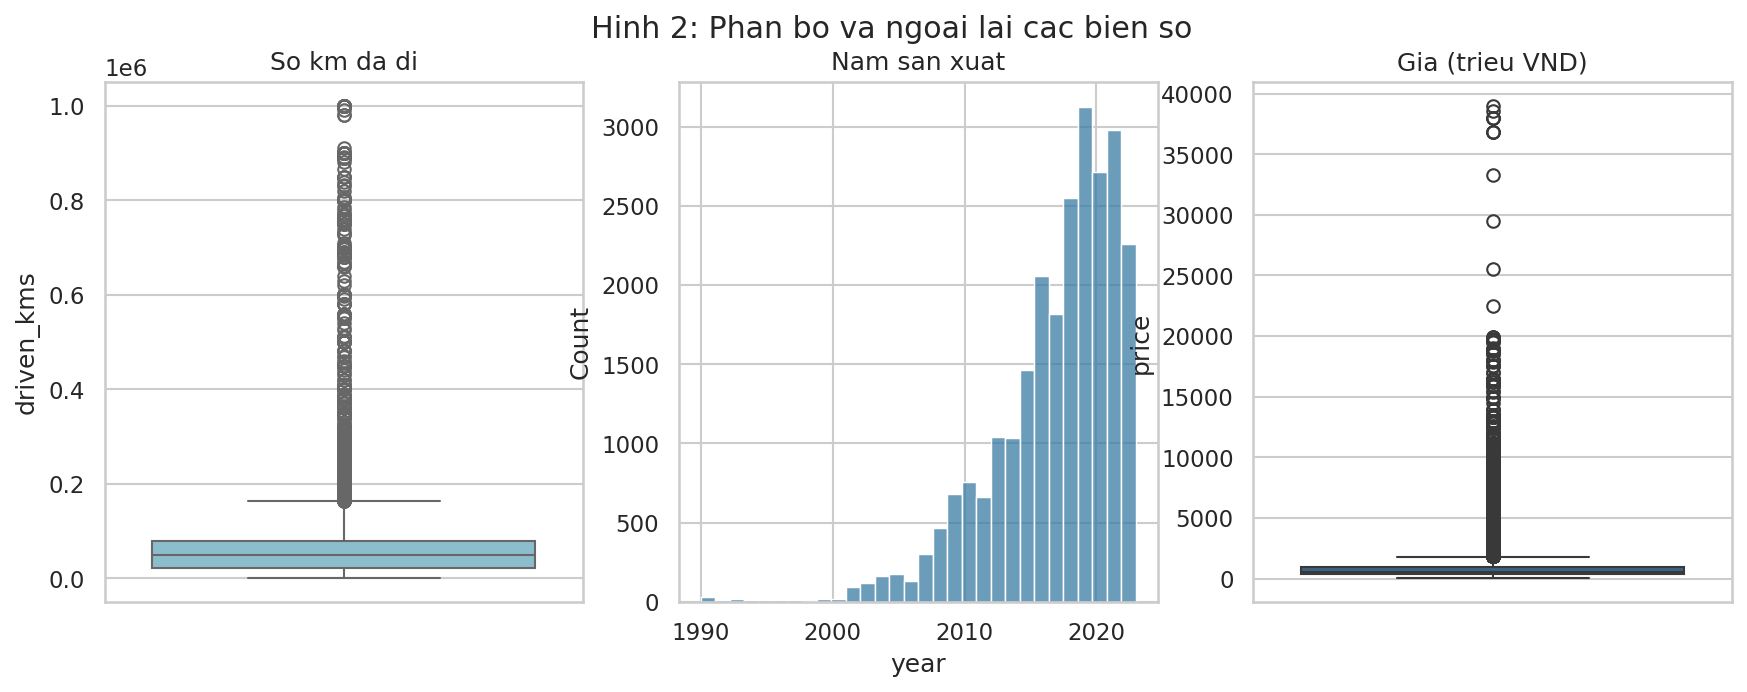

In [ ]:
img = mpimg.imread('../../docs/figures/02_numeric_distributions.png')
plt.figure(figsize=(14,4.5)); plt.imshow(img); plt.axis('off'); plt.show()

## Hinh 3: Ban do du lieu thieu

**Quan sat:** Phan lon cac cot thieu du lieu voi ty le nho (duoi vai %); mot so dong bi loi crawl dan den lech cot (vi du nam san xuat khong phai so).

**Y nghia:** Du lieu kha day du, khong can ky thuat dien khuyet phuc tap.

**Quyet dinh xu ly:** Bo (drop) cac dong thieu du lieu o cac truong quan trong (`price`, `year`, `driven_kms`, cac cot phan loai...) thay vi dien gia tri, vi ty le thieu nho va giu do tin cay cua du lieu.

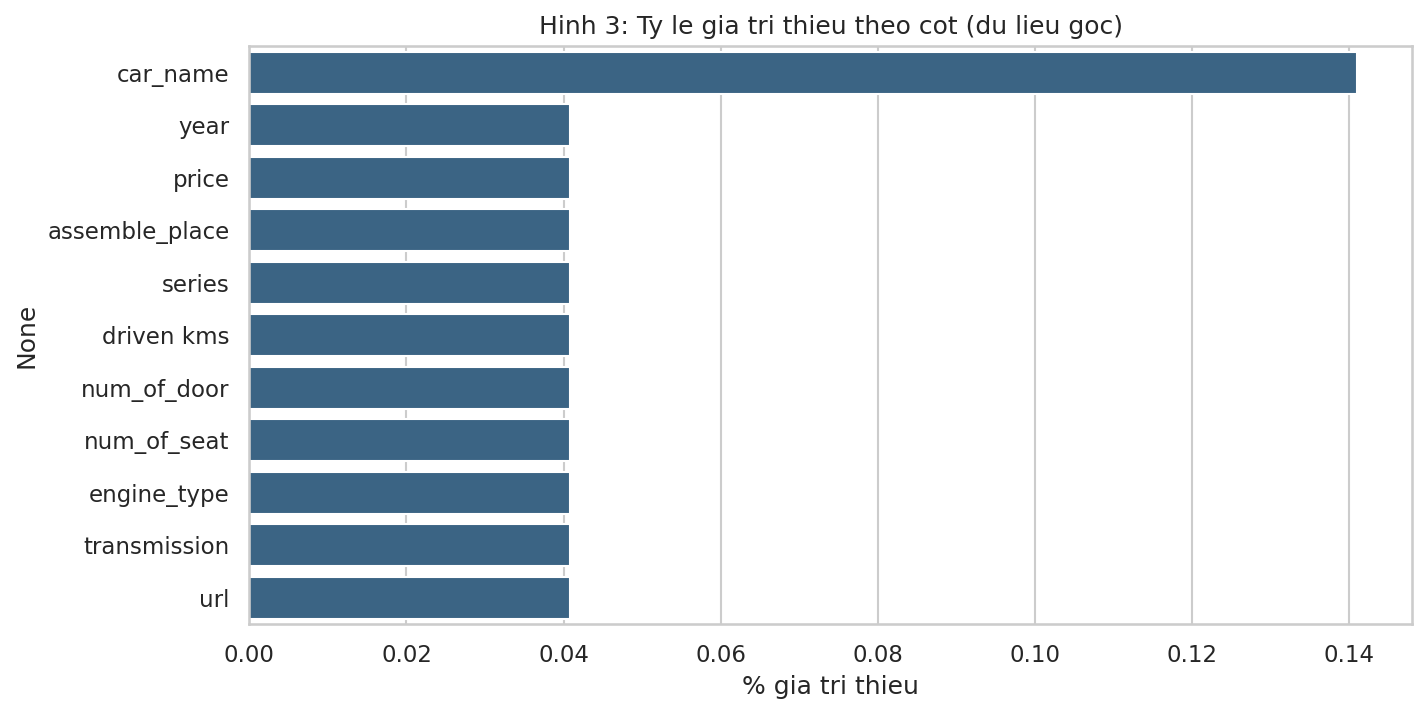

In [ ]:
img = mpimg.imread('../../docs/figures/03_missing_data.png')
plt.figure(figsize=(10,5)); plt.imshow(img); plt.axis('off'); plt.show()

## Hinh 4: Heatmap tuong quan cac bien so

**Quan sat:** `year` tuong quan duong voi `price` (xe moi hon -> dat hon); `driven_kms` tuong quan am nhe.

**Y nghia:** Cac bien so co lien he ro rang voi gia, hop ly de dua vao model; khong co cap bien so nao trung lap thong tin qua muc (khong can loai bo bien nao vi da cong tuyen).

**Quyet dinh xu ly:** Giu ca 4 bien so (`year`, `driven_kms`, `num_of_door`, `num_of_seat`) va chuan hoa bang `StandardScaler` truoc khi dua vao cac model nhay cam voi thang do (SVR).

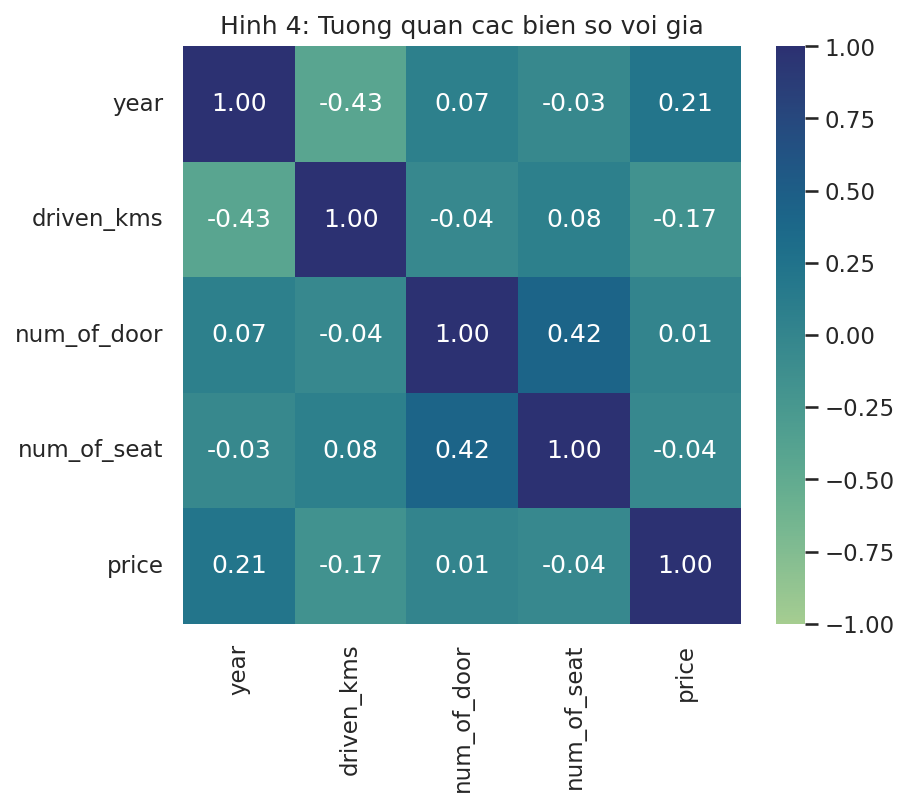

In [ ]:
img = mpimg.imread('../../docs/figures/04_correlation_heatmap.png')
plt.figure(figsize=(6,5)); plt.imshow(img); plt.axis('off'); plt.show()

## Hinh 5: Gia theo hang xe

**Quan sat:** Cac hang sang (vi du LandRover, Mercedes) co gia trung vi va do phan tan cao hon han cac hang binh dan (Kia, Mazda, Toyota).

**Y nghia:** `brand` la dac trung phan loai rat manh, anh huong lon den gia.

**Quyet dinh xu ly:** Ma hoa `brand` (va `model`, `series`) bang `OneHotEncoder(handle_unknown='ignore')` de model van du doan duoc khi gap hang/dong xe chua tung thay trong tap train.

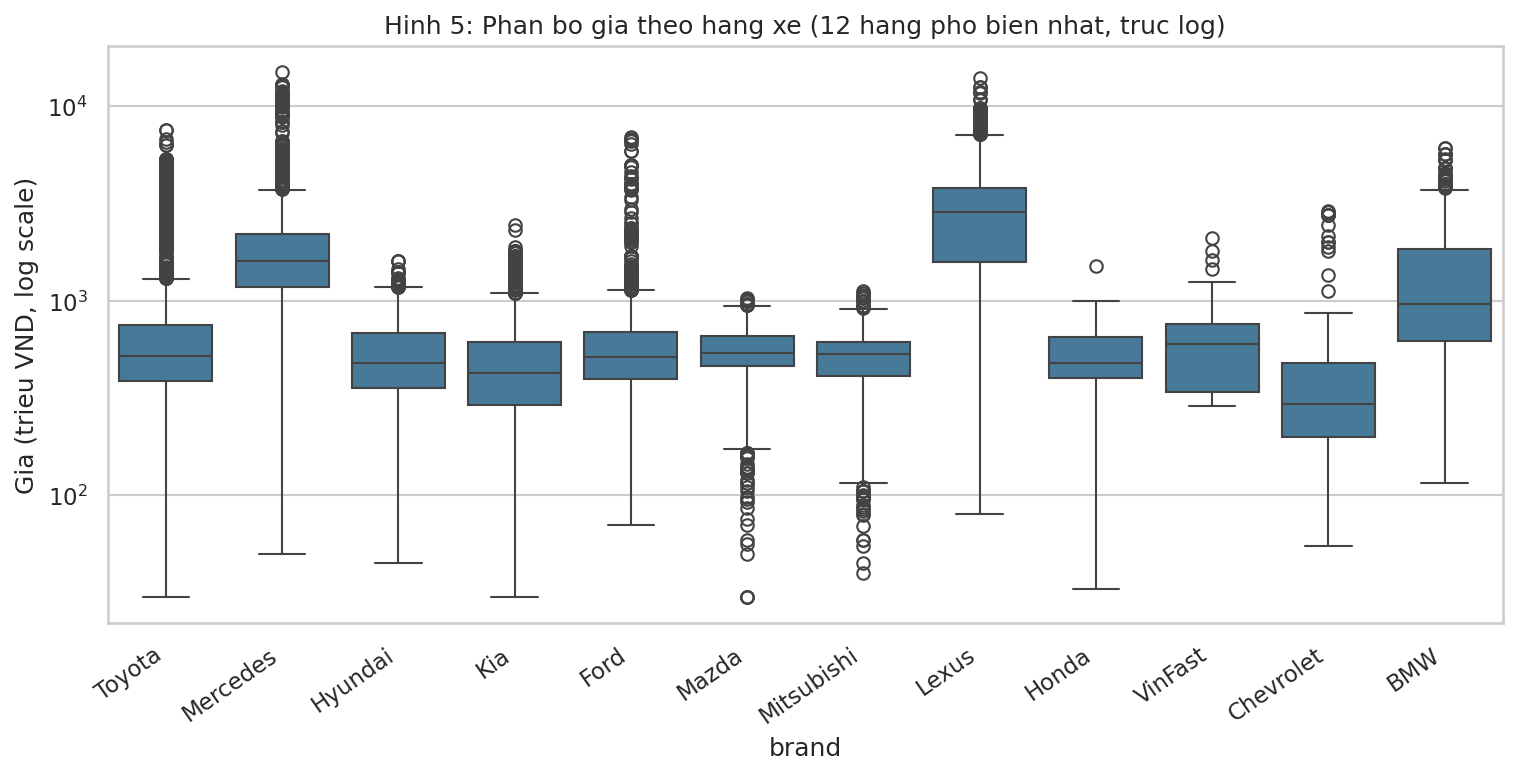

In [ ]:
img = mpimg.imread('../../docs/figures/05_price_by_brand.png')
plt.figure(figsize=(12,5)); plt.imshow(img); plt.axis('off'); plt.show()

## Hinh 6: Gia theo hop so va noi lap rap

**Quan sat:** Xe so tu dong va xe nhap khau co xu huong gia cao hon xe so san / lap rap trong nuoc.

**Y nghia:** `transmission` va `assemble_place` la cac dac trung phan loai co gia tri du doan.

**Quyet dinh xu ly:** Giu ca hai bien, ma hoa one-hot cung nhom voi `brand`, `series`, `engine_type`.

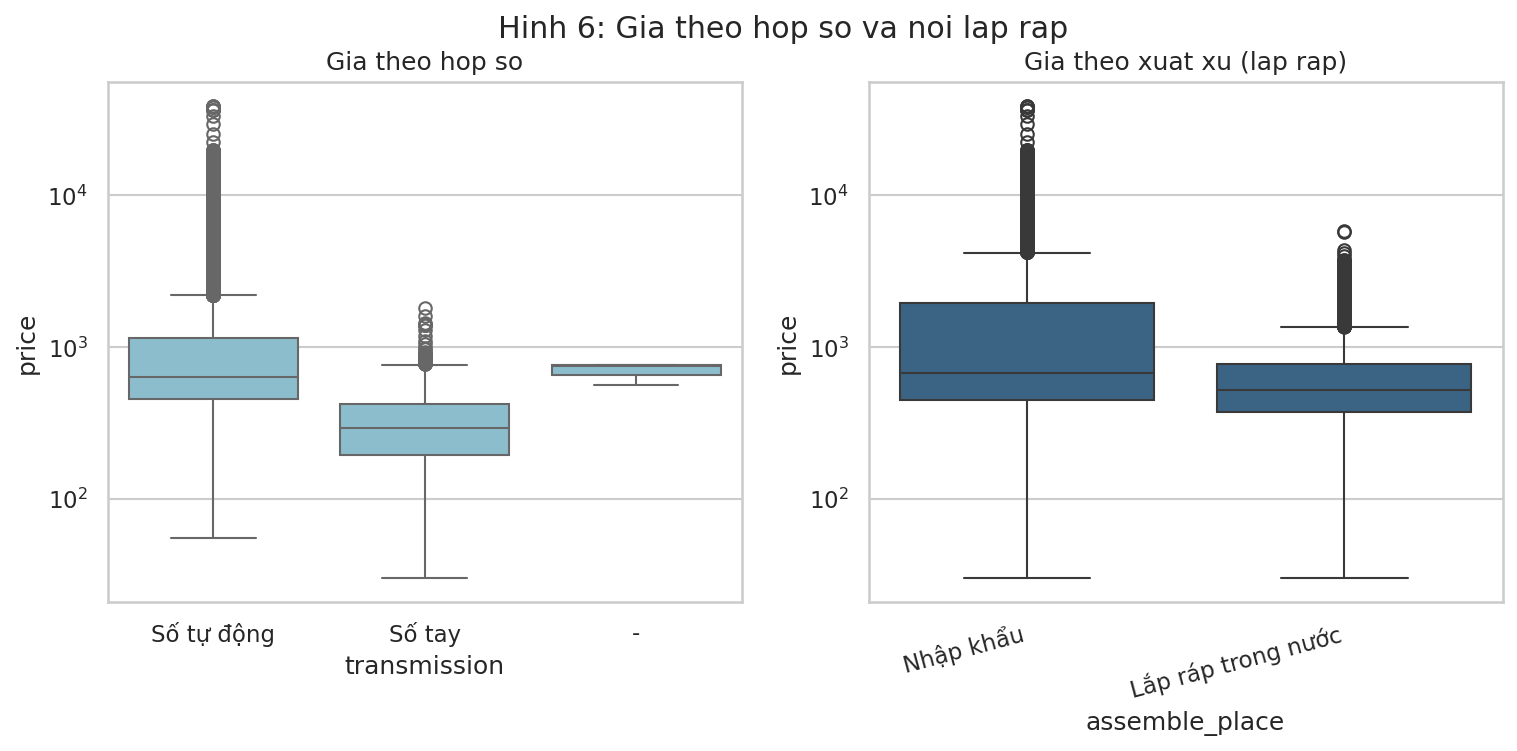

In [ ]:
img = mpimg.imread('../../docs/figures/06_price_by_transmission_origin.png')
plt.figure(figsize=(12,4.5)); plt.imshow(img); plt.axis('off'); plt.show()

## Hinh 7: Quan he km / nam san xuat voi gia

**Quan sat:** Gia giam dan khi so km tang (quan he phi tuyen, dang doc theo ham mu); xe san xuat cang gan day cang co gia cao hon ro ret.

**Y nghia:** Quan he phi tuyen goi y cac model phi tuyen (Decision Tree, Random Forest, SVR voi kernel RBF) co the nam bat tot hon Linear Regression.

**Quyet dinh xu ly:** Huan luyen ca model tuyen tinh (baseline) lan phi tuyen de so sanh; dung `log1p(price)` giup quan he voi cac bien so 'thang' hon.

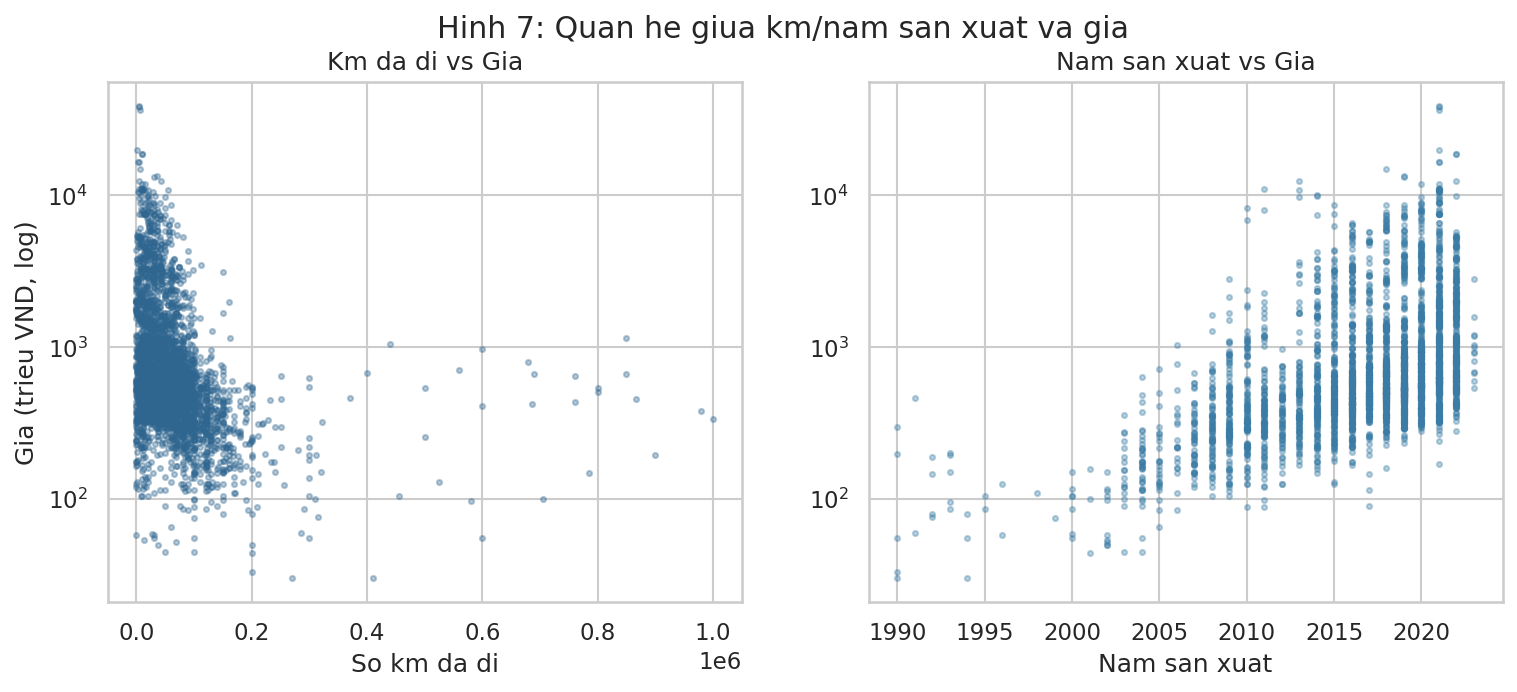

In [ ]:
img = mpimg.imread('../../docs/figures/07_scatter_kms_year_vs_price.png')
plt.figure(figsize=(12,4.5)); plt.imshow(img); plt.axis('off'); plt.show()

## Tong ket EDA -> quyet dinh cho buoc 2 (xu ly du lieu)

1. Bien target `price` lech phai -> dung `log1p` / `TransformedTargetRegressor`.
2. Loc ngoai lai: km <= 1.000.000, gia trong [30, 60.000] trieu, so cua [2,6], so cho [2,16], nam trong [1980,2027].
3. Bo dong thieu du lieu quan trong, bo trung theo `url`.
4. Bien so (`year`, `driven_kms`, `num_of_door`, `num_of_seat`) -> `StandardScaler`.
5. Bien phan loai (`brand`, `model`, `series`, `assemble_place`, `engine_type`, `transmission`) -> `OneHotEncoder(handle_unknown='ignore')`.
6. Tach truoc tap train/test roi moi fit scaler/encoder tren train de tranh **data leakage** (thuc hien trong notebook 03_train qua `Pipeline`).